In [ ]:
!pip install datasets scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import load_dataset

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix

In [3]:
dataset = load_dataset("Heliosoph/Jigsaw-Toxic-Comments")

train = dataset["train"].to_pandas()

train.head()

README.md:   0%|          | 0.00/8.74k [00:00<?, ?B/s]

train.csv.gz: reconstructing file:   0%|          |  0.00B / 26.7MB            

train.csv.gz: downloading bytes:           |  0.00B            

test.csv.gz: reconstructing file:   0%|          |  0.00B / 23.7MB            

test.csv.gz: downloading bytes:           |  0.00B            

test_labels.csv.gz: reconstructing file:   0%|          |  0.00B / 1.29MB            

test_labels.csv.gz: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
train["label"] = (
    train["toxic"] |
    train["severe_toxic"] |
    train["obscene"] |
    train["threat"] |
    train["insult"] |
    train["identity_hate"]
).astype(int)

In [5]:
X = train["comment_text"]

y = train["label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

In [8]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Linear SVM": LinearSVC(),

    "Naive Bayes": MultinomialNB()

}

results = []

best_model = None

best_name = ""

best_score = 0

In [9]:
for name, model in models.items():

    model.fit(X_train_vec, y_train)

    pred = model.predict(X_test_vec)

    score = f1_score(y_test, pred)

    print("="*60)
    print(name)
    print(classification_report(y_test, pred))

    results.append([name, score])

    if score > best_score:
        best_score = score
        best_model = model
        best_name = name

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     28670
           1       0.93      0.60      0.73      3245

    accuracy                           0.96     31915
   macro avg       0.94      0.80      0.85     31915
weighted avg       0.95      0.96      0.95     31915

Linear SVM
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28670
           1       0.88      0.70      0.78      3245

    accuracy                           0.96     31915
   macro avg       0.92      0.84      0.88     31915
weighted avg       0.96      0.96      0.96     31915

Naive Bayes
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     28670
           1       0.93      0.49      0.64      3245

    accuracy                           0.94     31915
   macro avg       0.94      0.74      0.80     31915
weighted avg       0.94      0.

In [10]:
results = pd.DataFrame(
    results,
    columns=["Model","F1"]
)

results

,Model,F1
0,Logistic Regression,0.733969
1,Linear SVM,0.777092
2,Naive Bayes,0.639221


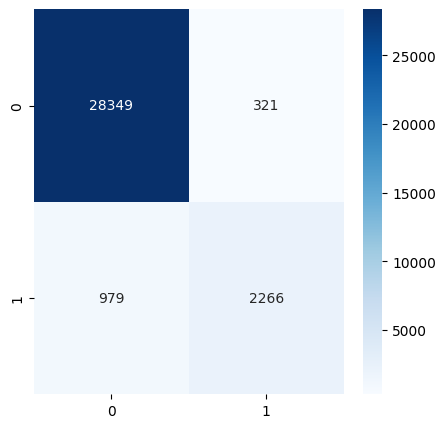

In [11]:
pred = best_model.predict(X_test_vec)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

In [12]:
joblib.dump(
    best_model,
    "toxicity_model.pkl"
)

joblib.dump(
    vectorizer,
    "toxicity_vectorizer.pkl"
)

['toxicity_vectorizer.pkl']

In [13]:
from google.colab import files

files.download("toxicity_model.pkl")
files.download("toxicity_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>